# Baseline vs P4 — interactive budget experiment

This notebook **replaces `swatch.sh`**. You drive the comparison cell-by-cell
with full control and visibility:

* **CONFIG** — every knob is an explicit literal. **What you type here is exactly
  what runs — there is no `config.yml` fallback.**
* **SETUP** (run once) — the notebook **trains its OWN initial model** (collect
  demos + train) into a config-keyed dir under `runs_nb/_bootstrap/`. It **never**
  reuses the Slurm `shared/init_*` cache. That single freshly-trained model is the
  **common start for baseline *and* p4** (that is what makes it apple-to-apple);
  **only the correction pool changes per run**. The heldout set is static (same
  200 layouts every round and every run).
* One **run cell per run** — `run_repetition(k)` does one budgeted run (baseline
  *and* p4 on the same correction pool), streams progress live, saves every
  component under `runs_nb/run_kk/`, renders the correction pool + its per-layout
  performance, and plots that run's learning curves.
* **REPLOT** — reads only `figures/notebook_runs.json` and redraws the aggregate
  for **any** number of runs with full control over colour / linewidth / opacity,
  **without re-running anything**.

**Sequential OpenAI:** Phase-B fan-out is forced to a single worker
(`P4_PHASE_B_MAX_WORKERS=1`), so every OpenAI call runs sequentially.

**Isolation:** the notebook writes only to `runs_nb/` and
`figures/notebook_runs.json`; the prior Slurm `runs/` and `figures/*.png` are
never touched.

> After any kernel restart, re-run **ENV BOOTSTRAP → CONFIG → SETUP** before any
> run cell. REPLOT only needs ENV BOOTSTRAP + the saved JSON.

## 1. Environment bootstrap *(run once per kernel)*

In [1]:
%matplotlib inline
import os, sys, gc, json, time, shutil
from pathlib import Path

# --- optional: pin a GPU BEFORE torch is imported (uncomment & edit) ---------
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"

REPO_ROOT = Path("/vast/s226137394/DmN/DmNfull")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Force OpenAI calls sequential (no Phase-B fan-out). Unset => Slurm default.
os.environ["P4_PHASE_B_MAX_WORKERS"] = "1"
# Headless pygame/SDL (safe for in-process env builds on a compute node).
os.environ.setdefault("SDL_VIDEODRIVER", "dummy")
os.environ.setdefault("SDL_AUDIODRIVER", "dummy")
os.environ.setdefault("PYGAME_HIDE_SUPPORT_PROMPT", "1")
os.chdir(REPO_ROOT)

from Equivariant_pathway.equivariant_CNN_hybrid.baseline_vs_p4 import (
    run_one, layout_setup, aggregate_chart, nb_helpers,
)
from Equivariant_pathway.equivariant_CNN_hybrid.baseline_vs_p4.baseline_budget import (
    run_baseline_budget,
)
from Equivariant_pathway.equivariant_CNN_hybrid.baseline_vs_p4.p4_budget import (
    run_p4_budget,
)
import matplotlib.pyplot as plt
# aggregate_chart imported above forces the Agg backend; re-assert inline.
get_ipython().run_line_magic("matplotlib", "inline")
import torch

print("cwd                   :", os.getcwd())
print("sys.path[0]           :", sys.path[0])
print("P4_PHASE_B_MAX_WORKERS:", os.environ["P4_PHASE_B_MAX_WORKERS"],
      "(1 => OpenAI calls run sequentially)")
print("torch.cuda available  :", torch.cuda.is_available(),
      "| device count:", torch.cuda.device_count())

cwd                   : /vast/s226137394/DmN/DmNfull
sys.path[0]           : /vast/s226137394/DmN/DmNfull
P4_PHASE_B_MAX_WORKERS: 1 (1 => OpenAI calls run sequentially)
torch.cuda available  : True | device count: 1


/home/s226137394/.conda/envs/maze/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. CONFIG — every knob is yours

Every value below is an explicit literal. **What you type here is exactly what runs — there is no `config.yml` fallback.** Edit, then re-run this cell; later run cells pick up the new values. Changing `INITIAL_DEMOS`, `INITIAL_EPOCHS` or `SEED` changes the bootstrap dir, so SETUP retrains a fresh model.

In [2]:
# Explicit literals — what you set here is exactly what runs.
# (Reference defaults live in config.yml but are intentionally NOT read here.)
BUDGET                = 10     # extra demos on top of the initial set (per method)
TARGET_SR             = 0.90   # stop a method once heldout SR >= this
INITIAL_DEMOS         = 20     # BFS demos the initial model is trained on
HELDOUT_N             = 200    # static heldout eval set size (same every round/run)
CORRECTION_N          = 40     # correction-pool size (the ONLY thing varying per run)
INITIAL_EPOCHS        = 500    # epochs to train the notebook's OWN initial model
ROUND_EPOCHS          = 500    # p4 epochs per correction round
BASELINE_ROUND_EPOCHS = 100    # baseline epochs per correction round
MAX_ROUNDS            = 50     # hard cap on correction rounds
MAX_STEPS             = 60     # max steps per rollout episode
SEED                  = 0      # global seed
TRAIN_FROM_SCRATCH    = True   # retrain (vs resume) each correction round
METHODS               = ["baseline", "p4"]   # methods each run executes
FORCE_RESTART         = True   # re-running an index wipes its prior outputs

NB_RUNS_DIR   = layout_setup.COMPARE_ROOT / "runs_nb"
NOTEBOOK_JSON = layout_setup.COMPARE_ROOT / "figures" / "notebook_runs.json"
NB_BOOT_DIR   = nb_helpers.notebook_bootstrap_dir(
    NB_RUNS_DIR, INITIAL_DEMOS, INITIAL_EPOCHS, SEED)
NB_RUNS_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_JSON.parent.mkdir(parents=True, exist_ok=True)

_resolved = {
    "BUDGET": BUDGET, "TARGET_SR": TARGET_SR, "INITIAL_DEMOS": INITIAL_DEMOS,
    "HELDOUT_N": HELDOUT_N, "CORRECTION_N": CORRECTION_N,
    "INITIAL_EPOCHS": INITIAL_EPOCHS, "ROUND_EPOCHS": ROUND_EPOCHS,
    "BASELINE_ROUND_EPOCHS": BASELINE_ROUND_EPOCHS, "MAX_ROUNDS": MAX_ROUNDS,
    "MAX_STEPS": MAX_STEPS, "SEED": SEED, "TRAIN_FROM_SCRATCH": TRAIN_FROM_SCRATCH,
    "METHODS": METHODS, "FORCE_RESTART": FORCE_RESTART,
}
print("resolved config (literals — no config.yml read):")
for k, v in _resolved.items():
    print(f"  {k:>22} : {v}")
print(f"\n  runs dir       : {NB_RUNS_DIR}")
print(f"  bootstrap dir  : {NB_BOOT_DIR}")
print(f"                   ^ the notebook trains its OWN initial model here")
print(f"  replot JSON    : {NOTEBOOK_JSON}")

resolved config (literals — no config.yml read):
                  BUDGET : 10
               TARGET_SR : 0.9
           INITIAL_DEMOS : 20
               HELDOUT_N : 200
            CORRECTION_N : 40
          INITIAL_EPOCHS : 500
            ROUND_EPOCHS : 500
   BASELINE_ROUND_EPOCHS : 100
              MAX_ROUNDS : 50
               MAX_STEPS : 60
                    SEED : 0
      TRAIN_FROM_SCRATCH : True
                 METHODS : ['baseline', 'p4']
           FORCE_RESTART : True

  runs dir       : /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_nb
  bootstrap dir  : /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_nb/_bootstrap/demos20_ep500_seed0
                   ^ the notebook trains its OWN initial model here
  replot JSON    : /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/figures/notebook_runs.json


## 3. SETUP — train the notebook's OWN initial model *(run once)*

Runs `collect_demos` + `train` into the config-keyed `runs_nb/_bootstrap/demos{D}_ep{E}_seed{S}/` dir. It **never** reads or writes the Slurm `shared/init_*` cache, so your config actually takes effect. Idempotent for a given `(INITIAL_DEMOS, INITIAL_EPOCHS, SEED)` — change any of those in CONFIG and re-run to retrain.

The heldout / training layout *specs* are seed-deterministic and reused as-is (so the heldout stays constant across runs); their counts are checked against your CONFIG and fail loudly on mismatch rather than silently serving stale layouts.

In [3]:
shared = layout_setup.ensure_shared_layouts(
    initial_demos=INITIAL_DEMOS, heldout_n=HELDOUT_N)

# Consistency guard: shared layout specs are seed-deterministic and reused so
# the heldout stays constant -- but if they were built with different counts
# (e.g. by the prior Slurm run) fail LOUDLY instead of serving stale layouts.
_nh = nb_helpers.count_layouts(shared["heldout"])
_nt = nb_helpers.count_layouts(shared["train"])
if _nh != HELDOUT_N or _nt != INITIAL_DEMOS:
    raise SystemExit(
        f"shared layout specs mismatch your CONFIG:\n"
        f"  heldout has {_nh} layouts (CONFIG HELDOUT_N={HELDOUT_N})\n"
        f"  training has {_nt} layouts (CONFIG INITIAL_DEMOS={INITIAL_DEMOS})\n"
        f"These YAMLs are shared with the Slurm pipeline:\n"
        f"  {shared['heldout']}\n  {shared['train']}\n"
        f"Either set HELDOUT_N/INITIAL_DEMOS back to the existing values, OR "
        f"move/rename those two YAMLs so they are regenerated at your counts "
        f"(this would also affect the Slurm runs/ if you reuse that path).")

# Train the notebook's OWN initial model into the config-keyed bootstrap dir.
# prefer_global=False => collect_demos + train run DIRECTLY here (a genuine
# fresh model); it never reads/writes the Slurm shared/init_* cache.
run_one._bootstrap_initial(
    seed=SEED, initial_epochs=INITIAL_EPOCHS, initial_demos=INITIAL_DEMOS,
    train_yaml=shared["train"],
    shared_demo_dir=NB_BOOT_DIR / "init_demos",
    shared_ckpt_dir=NB_BOOT_DIR / "init_checkpoints",
    prefer_global=False)

_nb_d = len(list((NB_BOOT_DIR / "init_demos").glob("*.json")))
_nb_c = (NB_BOOT_DIR / "init_checkpoints" / "best_hybrid_policy.pth").exists()
print("training layouts :", shared["train"], f"({_nt} layouts)")
print("heldout layouts  :", shared["heldout"], f"({_nh} layouts, static)")
print("bootstrap demos  :", NB_BOOT_DIR / "init_demos", f"({_nb_d} demos)")
print("bootstrap ckpt   :", NB_BOOT_DIR / "init_checkpoints",
      "(best_hybrid_policy.pth present)" if _nb_c else "(MISSING)")
assert _nb_d >= INITIAL_DEMOS and _nb_c, "bootstrap incomplete"
print(f"\nSETUP complete — the notebook trained its OWN initial model "
      f"({INITIAL_EPOCHS} epochs on {INITIAL_DEMOS} demos).")
print("NOTE: round-0 heldout SR of THIS model is the comparison's starting "
      "point. If it is already near TARGET_SR there is little headroom to\n"
      "      tell baseline vs p4 apart -> lower INITIAL_EPOCHS and/or raise "
      "TARGET_SR in CONFIG and re-run SETUP (now actually effective).")

[15:40:44] [run-one] $ /home/s226137394/.conda/envs/maze/bin/python -u -m Equivariant_pathway.collect_demos --layouts /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/shared/training_layouts.yaml --demo_dir /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_nb/_bootstrap/demos20_ep500_seed0/init_demos --num_demos 20 --seed 0
[eq-collect] 20 layouts in /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/shared/training_layouts.yaml
[eq-collect] saved demo_multimodal_heldout_001_1778910556831.json  (layout 1/20, start=[0, 0], goal=[3, 2], fires=[[0, 2], [0, 4], [4, 1]])
[eq-collect] saved demo_multimodal_heldout_002_1778910086818.json  (layout 2/20, start=[3, 0], goal=[1, 4], fires=[[0, 4], [2, 3], [3, 2]])
[eq-collect] saved demo_multimodal_heldout_003_1778910121268.json  (layout 3/20, start=[3, 1], goal=[0, 0], fires=[[1, 1], [1, 3], [3, 0]])
[eq-collect] saved demo_multimo

## 4. Run engine

`run_repetition(k)` performs one full budgeted run for `RUN_INDEX = k`.

* **Both baseline and p4 start from the *same* freshly-trained initial model** copied from `NB_BOOT_DIR` into `runs_nb/run_kk/shared/` — that shared, controlled start is what makes the comparison apple-to-apple; only the correction *strategy* differs.
* `[hybrid-rollout] N unique; running N eps` lines are **heldout evaluations** over the static heldout set (measuring `heldout_sr` each round) — **not** new demos.
* Within a run, baseline and p4 use the **identical** correction pool; the pool changes only **across** runs (seed `91_000_000 + RUN_INDEX`). The heldout set is the same 200 layouts for every round and every run.

Saves under `runs_nb/run_kk/`: `correction_pool_layouts.png`, `correction_pool_perf_baseline.png`/`_p4.png`, `correction_pool_performance.json`, `learning_curve_baseline_vs_p4.png`, `run_summary.json`, plus the usual `baseline_only/`, `p4_only/`, `shared/` trees; then appends to `figures/notebook_runs.json` (dedup by index).

In [4]:
def run_repetition(run_index: int):
    """One budgeted run (mirrors run_one.main phases) into runs_nb/run_NN/."""
    t0 = time.time()
    run_dir = NB_RUNS_DIR / f"run_{run_index:02d}"
    if FORCE_RESTART:
        # fully fresh: also clears shared/ so stale per-run init
        # demos/checkpoints from an earlier run can never leak in.
        shutil.rmtree(run_dir, ignore_errors=True)
    shared_run_dir = run_dir / "shared"
    run_dir.mkdir(parents=True, exist_ok=True)
    shared_run_dir.mkdir(parents=True, exist_ok=True)

    # --- Phase 1: static shared layouts (idempotent) + per-run pool ---------
    sh = layout_setup.ensure_shared_layouts(
        initial_demos=INITIAL_DEMOS, heldout_n=HELDOUT_N)
    correction_yaml = layout_setup.ensure_correction_layouts_for_run(
        run_index, CORRECTION_N,
        train_yaml=sh["train"], heldout_yaml=sh["heldout"],
        out_dir=shared_run_dir)
    print(f"[run {run_index:02d}] correction pool -> {correction_yaml}")

    pool = nb_helpers.load_pool(correction_yaml)
    nb_helpers.render_correction_pool(
        pool, out_png=run_dir / "correction_pool_layouts.png",
        title=f"run {run_index:02d} correction pool (n={len(pool)})")
    plt.show()

    # --- Phase 2: seed this run from the notebook's OWN trained model ------
    #     (copied from NB_BOOT_DIR; never the Slurm shared/init_* cache).
    #     Both baseline and p4 below start from this same model.
    shared_demo_dir, shared_ckpt_dir = nb_helpers.seed_run_from_bootstrap(
        NB_BOOT_DIR, shared_run_dir, INITIAL_DEMOS)

    bo_root = run_dir / "baseline_only"
    p4_root = run_dir / "p4_only"
    # run_dir already wiped above when FORCE_RESTART; just (re)create.
    bo_root.mkdir(parents=True, exist_ok=True)
    p4_root.mkdir(parents=True, exist_ok=True)

    result_bo = result_p4 = None
    # --- Phase 3a: baseline (no OpenAI) ------------------------------------
    if "baseline" in METHODS:
        print(f"\n{'='*80}\n[run {run_index:02d}] BASELINE budget loop\n{'='*80}")
        result_bo = run_baseline_budget(
            run_index=run_index, bo_root=bo_root,
            shared_demo_dir=shared_demo_dir, shared_ckpt_dir=shared_ckpt_dir,
            correction_yaml=correction_yaml, heldout_yaml=sh["heldout"],
            budget=BUDGET, target_sr=TARGET_SR,
            round_epochs=BASELINE_ROUND_EPOCHS, max_rounds=MAX_ROUNDS,
            max_steps=MAX_STEPS, seed=SEED,
            train_from_scratch=TRAIN_FROM_SCRATCH)

    # --- Phase 3b: p4 (sequential OpenAI via P4_PHASE_B_MAX_WORKERS=1) ------
    if "p4" in METHODS:
        print(f"\n{'='*80}\n[run {run_index:02d}] P4 budget loop "
              f"(sequential OpenAI)\n{'='*80}")
        result_p4 = run_p4_budget(
            run_index=run_index, p4_root=p4_root,
            shared_demo_dir=shared_demo_dir, shared_ckpt_dir=shared_ckpt_dir,
            correction_yaml=correction_yaml, heldout_yaml=sh["heldout"],
            budget=BUDGET, target_sr=TARGET_SR,
            round_epochs=ROUND_EPOCHS, max_rounds=MAX_ROUNDS,
            max_steps=MAX_STEPS, seed=SEED,
            train_from_scratch=TRAIN_FROM_SCRATCH)

    # --- run summary -------------------------------------------------------
    summary = {
        "run_index": run_index, "budget": BUDGET, "target_sr": TARGET_SR,
        "correction_yaml": str(correction_yaml),
        "heldout_yaml": str(sh["heldout"]), "training_yaml": str(sh["train"]),
        "bootstrap_dir": str(NB_BOOT_DIR),
        "baseline_stopped_reason": (result_bo or {}).get("stopped_reason"),
        "p4_stopped_reason": (result_p4 or {}).get("stopped_reason"),
    }
    with open(run_dir / "run_summary.json", "w") as f:
        json.dump(summary, f, indent=2, default=str)
    print("\n[run %02d] summary: %s" % (
        run_index, json.dumps(summary, indent=2, default=str)))

    # --- correction-pool performance: data + tinted thumbnails -------------
    perf = nb_helpers.correction_pool_performance(
        run_index, BUDGET, TARGET_SR, pool, bo_root, p4_root, METHODS)
    with open(run_dir / "correction_pool_performance.json", "w") as f:
        json.dump(perf, f, indent=2, default=str)
    if "baseline" in METHODS and perf.get("baseline"):
        nb_helpers.render_correction_pool(
            pool, success_map=perf["baseline"]["final_success_map"],
            out_png=run_dir / "correction_pool_perf_baseline.png",
            title=f"run {run_index:02d} baseline correction-pool perf "
                  f"(round {perf['baseline']['final_round']})")
        plt.show()
    if "p4" in METHODS and perf.get("p4"):
        nb_helpers.render_correction_pool(
            pool, success_map=perf["p4"]["final_success_map"],
            out_png=run_dir / "correction_pool_perf_p4.png",
            title=f"run {run_index:02d} p4 correction-pool perf "
                  f"(round {perf['p4']['final_round']})")
        plt.show()

    # --- per-run learning curve -------------------------------------------
    nb_helpers.plot_single_run(
        nb_helpers.read_learning_curve(bo_root / "results"),
        nb_helpers.read_learning_curve(p4_root / "results"),
        TARGET_SR, out_png=run_dir / "learning_curve_baseline_vs_p4.png",
        title=f"run {run_index:02d}: baseline vs p4")
    plt.show()

    # --- append to the self-contained replot JSON (dedup by index) ---------
    nb_helpers.append_run_to_notebook_json(
        NOTEBOOK_JSON, run_index, BUDGET, TARGET_SR, METHODS, bo_root, p4_root)

    gc.collect()
    try:
        torch.cuda.empty_cache()
    except Exception:
        pass
    print(f"\n[run {run_index:02d}] DONE in {time.time()-t0:.1f}s "
          f"-> {run_dir}")
    return summary

## 5. Runs

Each run cell below is one repetition. **To add more runs: duplicate the cell and bump the index** (`run_repetition(3)`, `run_repetition(4)`, …). Indices map to `runs_nb/run_NN/`; the correction pool for index `k` is deterministic (seed `91_000_000 + k`), and every run reuses the same notebook-trained initial model + the same static heldout set.

### Run 0

[layout-sampler] wrote 40 layouts -> /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_nb/run_00/shared/correction_layouts.yaml
[run 00] correction pool -> /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_nb/run_00/shared/correction_layouts.yaml
[nb] wrote /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_nb/run_00/correction_pool_layouts.png


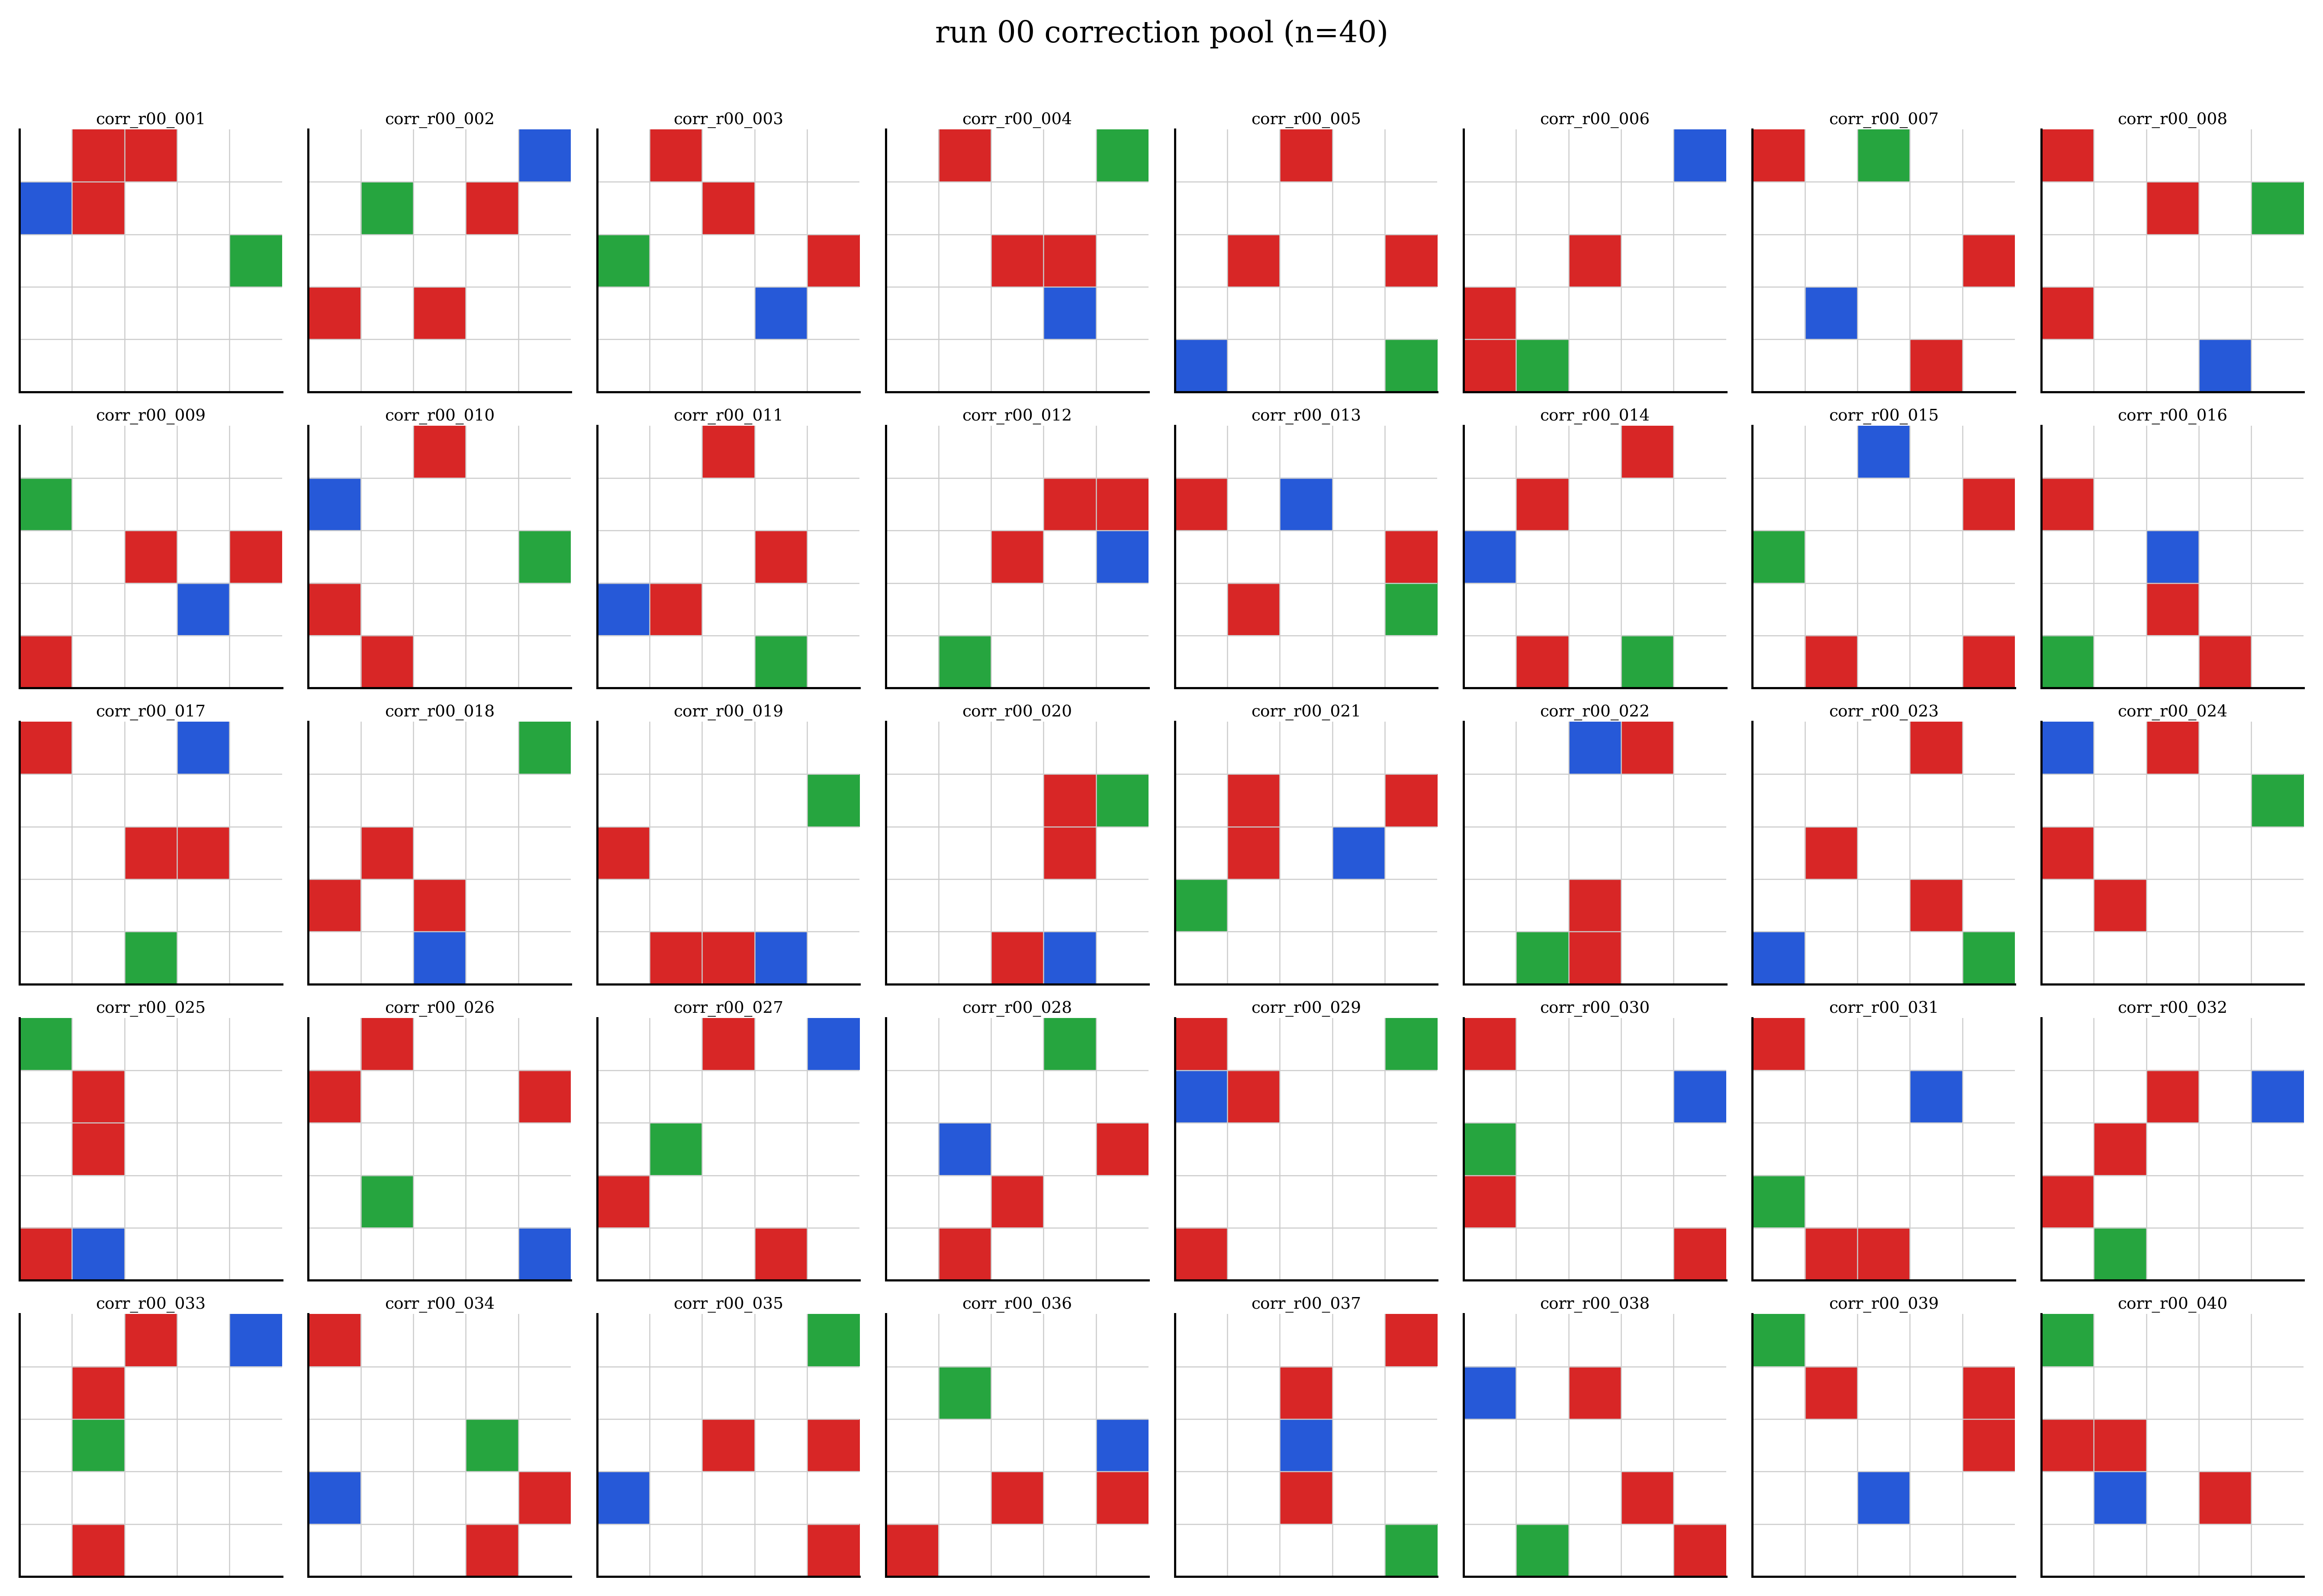

[nb] seeded run from bootstrap: 20 init demos + checkpoint -> /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_nb/run_00/shared

[run 00] BASELINE budget loop
[15:43:47] [bo-budget] $ /home/s226137394/.conda/envs/maze/bin/python -u -m Equivariant_pathway.equivariant_CNN_hybrid.rollout_test --checkpoint /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_nb/run_00/baseline_only/checkpoints/best_hybrid_policy.pth --layouts /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/shared/heldout_layouts.yaml --out_dir /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_nb/run_00/baseline_only/results/eval_round_000 --seed 0 --max_steps 60
[hybrid-rollout] 200 unique; running 200 eps
[hybrid-rollout] loaded /vast/s226137394/DmN/DmNfull/Equivariant_pathway/equivariant_CNN_hybrid/baseline_vs_p4/runs_nb/run_00/baseline_only/checkpoints/best_hy

/home/s226137394/.conda/envs/maze/lib/python3.11/site-packages/pygame/sysfont.py:226: UserWarning: Process running 'fc-list' timed-out! System fonts cannot be loaded on your platform
  warnings.warn(


[hybrid-rollout] ep 0 (corr_r00_001): steps=5 success=True
[hybrid-rollout] ep 1 (corr_r00_002): steps=4 success=True
[hybrid-rollout] ep 2 (corr_r00_003): steps=6 success=True
[hybrid-rollout] ep 3 (corr_r00_004): steps=60 success=False
[hybrid-rollout] ep 4 (corr_r00_005): steps=4 success=True
[hybrid-rollout] ep 5 (corr_r00_006): steps=7 success=True
[hybrid-rollout] ep 6 (corr_r00_007): steps=60 success=False
[hybrid-rollout] ep 7 (corr_r00_008): steps=60 success=False
[hybrid-rollout] ep 8 (corr_r00_009): steps=5 success=True
[hybrid-rollout] ep 9 (corr_r00_010): steps=5 success=True
[hybrid-rollout] ep 10 (corr_r00_011): steps=4 success=True
[hybrid-rollout] ep 11 (corr_r00_012): steps=60 success=False
[hybrid-rollout] ep 12 (corr_r00_013): steps=4 success=True
[hybrid-rollout] ep 13 (corr_r00_014): steps=5 success=True
[hybrid-rollout] ep 14 (corr_r00_015): steps=4 success=True
[hybrid-rollout] ep 15 (corr_r00_016): steps=60 success=False
[hybrid-rollout] ep 16 (corr_r00_017): s

In [ ]:
run_repetition(0)

### Run 1  *(duplicate this pair and bump the index for more)*

In [ ]:
run_repetition(1)

### Run 2

In [ ]:
run_repetition(2)

## 6. REPLOT — aggregate from saved JSON *(no re-run)*

Reads **only** `figures/notebook_runs.json`. Works after a kernel restart with just the ENV BOOTSTRAP cell. Edit the styling knobs and re-run this cell alone to restyle — nothing is recomputed. Works for any number of runs.

In [ ]:
import numpy as np
from Equivariant_pathway.equivariant_CNN_hybrid.baseline_vs_p4.aggregate_chart import (
    _sample_hold,
)

# ----------------------- styling knobs (edit freely) -----------------------
BASELINE_COLOR   = "tab:orange"
P4_COLOR         = "tab:purple"
MEAN_LINEWIDTH   = 1.8
PERRUN_LINEWIDTH = 0.8
PERRUN_ALPHA     = 0.18
BAND_ALPHA       = 0.18
SHOW_PERRUN      = True
FIGSIZE          = (7.5, 4.5)
TITLE            = None          # e.g. "Baseline vs P4 (sequential)"
# ---------------------------------------------------------------------------

_json = globals().get("NOTEBOOK_JSON") or (
    layout_setup.COMPARE_ROOT / "figures" / "notebook_runs.json")
data = nb_helpers.load_notebook_json(_json)
runs = data.get("runs", []) or []
budget = int(data.get("budget") or globals().get("BUDGET", 10))
target = float(data.get("target_sr") or globals().get("TARGET_SR", 0.90))
x_grid = np.arange(0, budget + 1, dtype=int)
print(f"replotting {len(runs)} run(s) from {_json} (budget={budget})")

if nb_helpers.STYLE_PATH.exists():
    plt.style.use(str(nb_helpers.STYLE_PATH))
colors = {"baseline_only": BASELINE_COLOR, "p4_only": P4_COLOR}
labels = {"baseline_only": "Baseline-DAgger (top-K by loss)",
          "p4_only": "P4 LLM (budgeted prescription)"}

fig, ax = plt.subplots(figsize=FIGSIZE)
for m in ("baseline_only", "p4_only"):
    rows = [r[m] for r in runs if r.get(m) and r[m].get("xs")]
    if not rows:
        continue
    Y = np.vstack([_sample_hold(b["xs"], b["ys"], x_grid) for b in rows])
    c = colors[m]
    if SHOW_PERRUN:
        for y in Y:
            ax.plot(x_grid, y, color=c, alpha=PERRUN_ALPHA,
                    linewidth=PERRUN_LINEWIDTH)
    mean = Y.mean(axis=0)
    std = Y.std(axis=0, ddof=0)
    ax.plot(x_grid, mean, color=c, marker="o", markersize=4,
            linewidth=MEAN_LINEWIDTH,
            label=f"{labels[m]}  (mean, n={Y.shape[0]})")
    ax.fill_between(x_grid, mean - std, mean + std, color=c,
                    alpha=BAND_ALPHA, linewidth=0)

ax.axhline(target, ls="--", color="tab:red", alpha=0.7,
           label=f"target = {target:.2f}")
ax.set_xlabel("extra demonstrations (on top of initial set)")
ax.set_ylabel("heldout success rate")
ax.set_xlim(0, budget)
ax.set_ylim(0, 1.05)
if TITLE:
    ax.set_title(TITLE)
ax.legend(loc="lower right", fontsize=8, framealpha=0.9)
fig.tight_layout()
_out = layout_setup.COMPARE_ROOT / "figures" / "notebook_aggregate.png"
fig.savefig(_out)
print("wrote", _out)
plt.show()